# Laboratorio 03  Modelos de Regresión Lineal
## InmoValor S.A.  Predicción del Precio de Venta de Viviendas

In [53]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, boxcox

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.feature_selection import RFE

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100,
})
sns.set_theme(style='whitegrid', palette='muted')

print("Librerías cargadas correctamente.")
print(f"   NumPy     {np.__version__}")
print(f"   Pandas    {pd.__version__}")


Librerías cargadas correctamente.
   NumPy     2.4.3
   Pandas    3.0.1


## Actividad 1 - Descarga del dataset


In [54]:
df = pd.read_csv('train.csv')

print(f"Dimensiones del dataset: {df.shape}")
print(f"  → {df.shape[0]} observaciones (casas)")
print(f"  → {df.shape[1]} variables (columnas)")


Dimensiones del dataset: (1460, 81)
  → 1460 observaciones (casas)
  → 81 variables (columnas)


In [55]:
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [56]:
dtype_counts = df.dtypes.value_counts()
print("Tipos de datos:")
print(dtype_counts)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nVariables numéricas : {len(num_cols)}")
print(f"Variables categóricas: {len(cat_cols)}")


Tipos de datos:
str        43
int64      35
float64     3
Name: count, dtype: int64

Variables numéricas : 38
Variables categóricas: 43


In [57]:
df[num_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])


,count,mean,std,min,25%,50%,75%,max
Id,1460.000000,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.000000,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.000000,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.000000,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.000000,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.000000,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.000000,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.000000,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.000000,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000


In [58]:
df[cat_cols].describe().T


,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


## Actividades 2  - Análisis Exploratorio de Datos

### Actividad 2.1 Análisis de Valores Nulos

Identificamos 19 columnas con valores faltantes. Es fundamental entender **por qué** faltan estos datos antes de decidir cómo tratarlos:

- **Nulos estructurales (>80%):** `PoolQC` (99.5%), `MiscFeature` (96.3%), `Alley` (93.8%), `Fence` (80.8%) y `MasVnrType` (59.7%) — en estos casos, `NA` **no significa dato faltante**, sino **ausencia de la característica** (sin piscina, sin callejón, sin cerca). Se rellenarán con la categoría `'None'` o `0`.
- **Nulos informativos (~5%):** Variables de garaje (`GarageYrBlt`, `GarageCond`, etc.) — la casa no tiene garaje. Mismo tratamiento.
- **Nulos aleatorios (<20%):** `LotFrontage` (17.7%) — dato genuinamente faltante, se imputa con la mediana por vecindario para preservar la variabilidad geográfica.


In [59]:
# Porcentaje de valores nulos por columna
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_df = null_pct[null_pct > 0].reset_index()
null_df.columns = ['Variable', 'Porcentaje_Nulo']
null_df['Cantidad'] = df[null_df['Variable']].isnull().sum().values

print(f"Columnas con valores nulos: {len(null_df)}")
print(null_df.to_string(index=False))


Columnas con valores nulos: 19
    Variable  Porcentaje_Nulo  Cantidad
      PoolQC        99.520548      1453
 MiscFeature        96.301370      1406
       Alley        93.767123      1369
       Fence        80.753425      1179
  MasVnrType        59.726027       872
 FireplaceQu        47.260274       690
 LotFrontage        17.739726       259
  GarageQual         5.547945        81
GarageFinish         5.547945        81
  GarageType         5.547945        81
 GarageYrBlt         5.547945        81
  GarageCond         5.547945        81
BsmtFinType2         2.602740        38
BsmtExposure         2.602740        38
    BsmtCond         2.534247        37
    BsmtQual         2.534247        37
BsmtFinType1         2.534247        37
  MasVnrArea         0.547945         8
  Electrical         0.068493         1


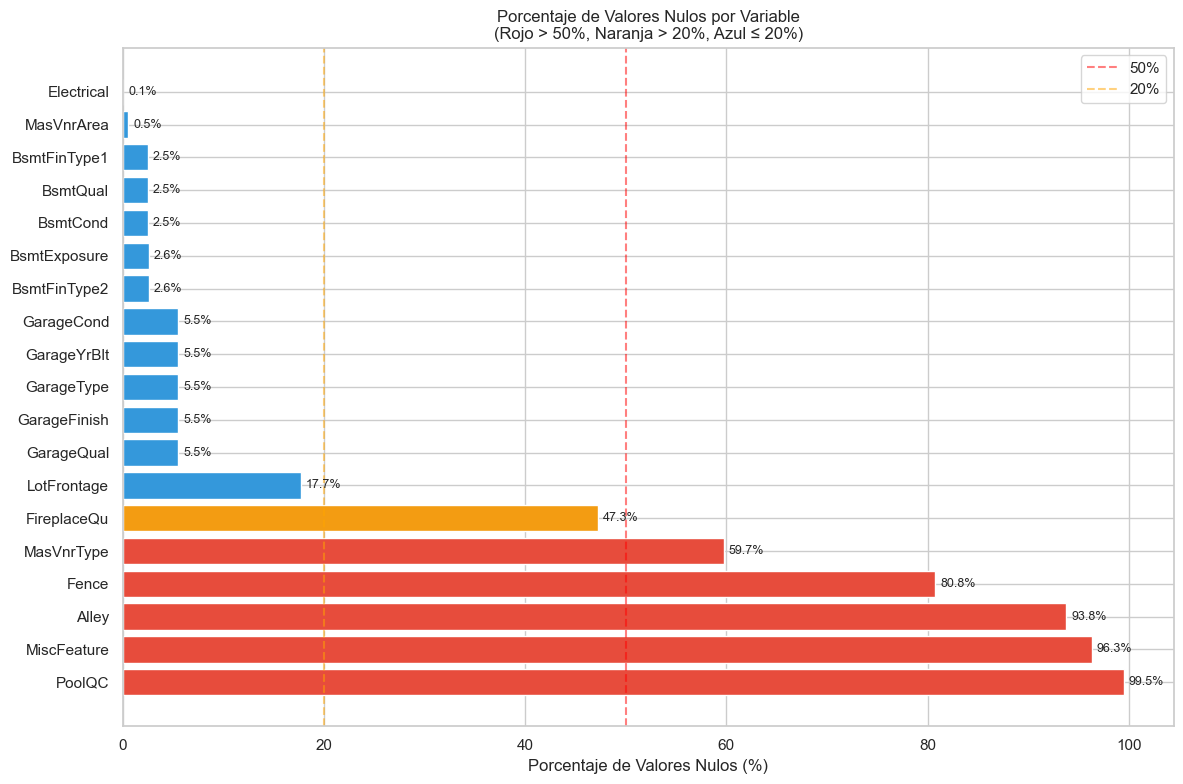

In [60]:
# Visualización de valores nulos
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#3498db'
          for x in null_df['Porcentaje_Nulo']]
bars = ax.barh(null_df['Variable'], null_df['Porcentaje_Nulo'], color=colors)
ax.set_xlabel('Porcentaje de Valores Nulos (%)')
ax.set_title('Porcentaje de Valores Nulos por Variable\n(Rojo > 50%, Naranja > 20%, Azul ≤ 20%)')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20%')
ax.legend()
for bar, val in zip(bars, null_df['Porcentaje_Nulo']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 2.2 Análisis de la Variable Respuesta: `SalePrice`

Antes de modelar, debemos entender la distribución de la variable que queremos predecir. Si `SalePrice` no es aproximadamente normal, los supuestos de la regresión lineal pueden verse afectados.


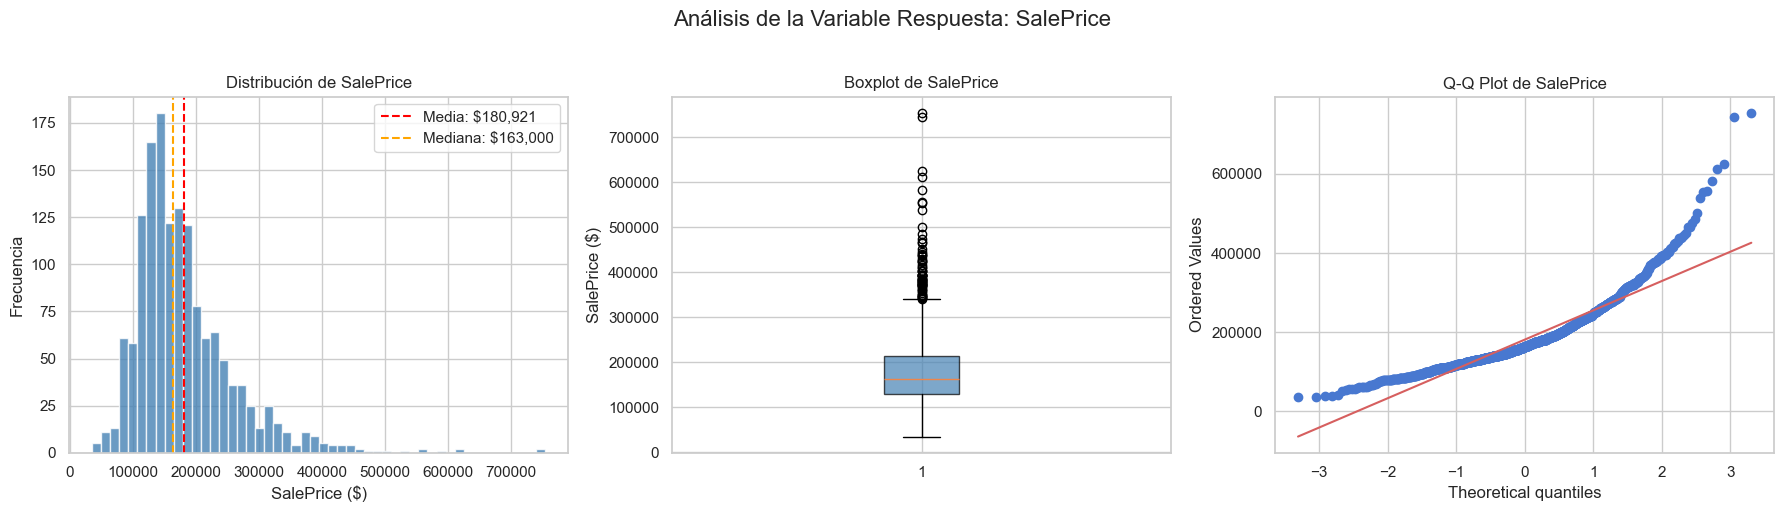

Asimetría (skewness): 1.8829
Curtosis (kurtosis) : 6.5363
Shapiro-Wilk (n≤5000): stat=0.8697, p-value=0.000000

→ NO sigue distribución normal (p < 0.05)


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Media: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='orange', linestyle='--', label=f'Mediana: ${df["SalePrice"].median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['SalePrice'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot de SalePrice')
axes[1].set_ylabel('SalePrice ($)')

# Q-Q Plot
stats.probplot(df['SalePrice'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot de SalePrice')

plt.suptitle('Análisis de la Variable Respuesta: SalePrice', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Estadísticas clave
skew = df['SalePrice'].skew()
kurt = df['SalePrice'].kurtosis()
stat_sw, p_sw = shapiro(df['SalePrice'].sample(min(5000, len(df)), random_state=RANDOM_STATE))
print(f"Asimetría (skewness): {skew:.4f}")
print(f"Curtosis (kurtosis) : {kurt:.4f}")
print(f"Shapiro-Wilk (n≤5000): stat={stat_sw:.4f}, p-value={p_sw:.6f}")
print(f"\n→ {'NO sigue distribución normal (p < 0.05)' if p_sw < 0.05 else 'Posible distribución normal (p ≥ 0.05)'}")


### 2.3 Prueba de Normalidad y Transformación de `SalePrice`

**Resultados del test Shapiro-Wilk:**
- `SalePrice` original: asimetría = **1.88**, p-value ≈ 0 → **rechazamos normalidad**
- `log1p(SalePrice)`: asimetría = **0.12** → distribución casi simétrica

La transformación logarítmica reduce drásticamente la asimetría. Esto es importante porque los supuestos de regresión lineal asumen que los residuos (no necesariamente la variable respuesta) son normales. Con `SalePrice` muy sesgado, los residuos también tenderán a ser asimétricos. Los modelos de esta práctica trabajan con `SalePrice` en escala original para mantener interpretabilidad directa en dólares, pero se documenta esta transformación como alternativa de mejora.


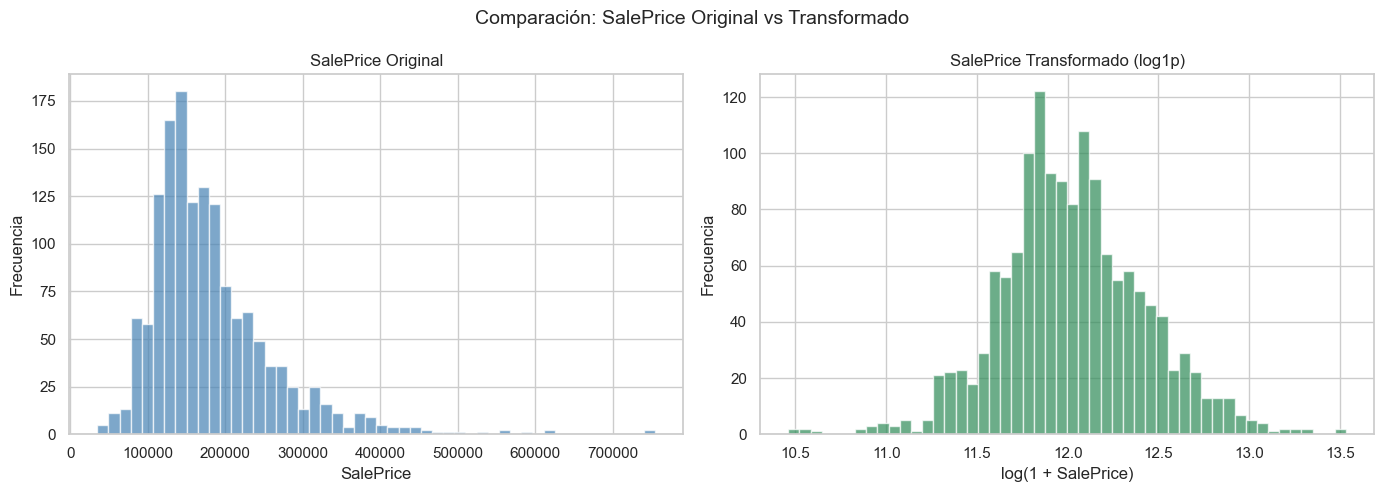

Después de transformación log:
  Asimetría: 0.1213  (original: 1.8829)
  Shapiro-Wilk: p = 0.000000

→ La transformación logarítmica reduce la asimetría significativamente,
   mejorando el cumplimiento de supuestos de normalidad.


In [62]:
# Transformación logarítmica
df['SalePrice_log'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original vs Log
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.7, label='Original')
axes[0].set_title('SalePrice Original')
axes[0].set_xlabel('SalePrice')

axes[1].hist(df['SalePrice_log'], bins=50, color='seagreen', edgecolor='white', alpha=0.7, label='log(1+SalePrice)')
axes[1].set_title('SalePrice Transformado (log1p)')
axes[1].set_xlabel('log(1 + SalePrice)')

for ax in axes:
    ax.set_ylabel('Frecuencia')

plt.suptitle('Comparación: SalePrice Original vs Transformado', fontsize=14)
plt.tight_layout()
plt.show()

# Prueba de normalidad en log
stat_log, p_log = shapiro(df['SalePrice_log'].sample(min(5000, len(df)), random_state=RANDOM_STATE))
skew_log = df['SalePrice_log'].skew()
print(f"Después de transformación log:")
print(f"  Asimetría: {skew_log:.4f}  (original: {df['SalePrice'].skew():.4f})")
print(f"  Shapiro-Wilk: p = {p_log:.6f}")
print("\n→ La transformación logarítmica reduce la asimetría significativamente,")
print("   mejorando el cumplimiento de supuestos de normalidad.")


### 2.4 Matriz de Correlaciones

**Hallazgos clave:**

| Variable | Correlación con SalePrice | Interpretación |
|---|---|---|
| `OverallQual` | **0.791** | La calidad general es el predictor más potente |
| `GrLivArea` | 0.709 | A mayor área habitable, mayor precio |
| `GarageCars` | 0.640 | Capacidad del garaje refleja nivel socioeconómico |
| `TotalBsmtSF` | 0.614 | Sótano grande = casa grande y más cara |
| `YearBuilt` | 0.523 | Casas más nuevas son más caras |
| `EnclosedPorch` | -0.129 | Porches cerrados se asocian a propiedades más antiguas/baratas |

**Conclusión:** Existe un grupo de variables relacionadas con tamaño y calidad que dominan la predicción de precios. La alta correlación entre varias de ellas (p.ej. `GrLivArea`, `1stFlrSF`, `TotalBsmtSF`) anticipa **multicolinealidad** en el modelo múltiple.


In [63]:
# Correlaciones con SalePrice
corr_with_target = df[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print("Top 15 variables con mayor correlación positiva con SalePrice:")
print(corr_with_target.head(15).to_string())
print("\nTop 5 variables con mayor correlación negativa:")
print(corr_with_target.tail(5).to_string())


Top 15 variables con mayor correlación positiva con SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799

Top 5 variables con mayor correlación negativa:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907


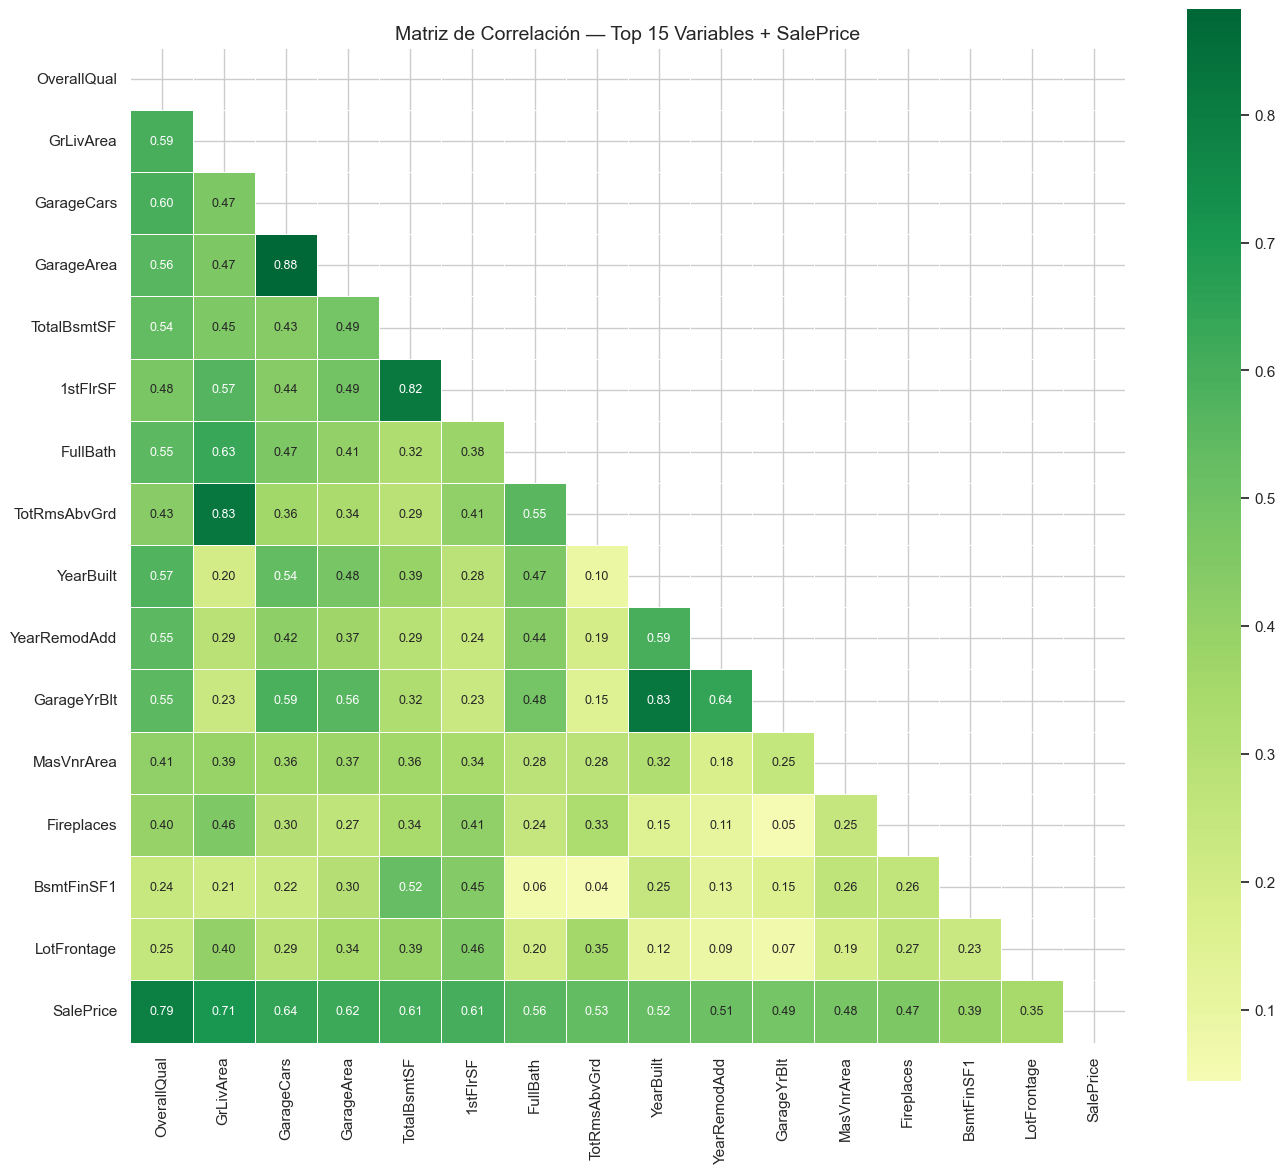

In [64]:
# Heatmap de las 15 variables más correlacionadas
top_corr_cols = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()
top_corr_cols.append('SalePrice')

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df[top_corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlación — Top 15 Variables + SalePrice', fontsize=14)
plt.tight_layout()
plt.show()


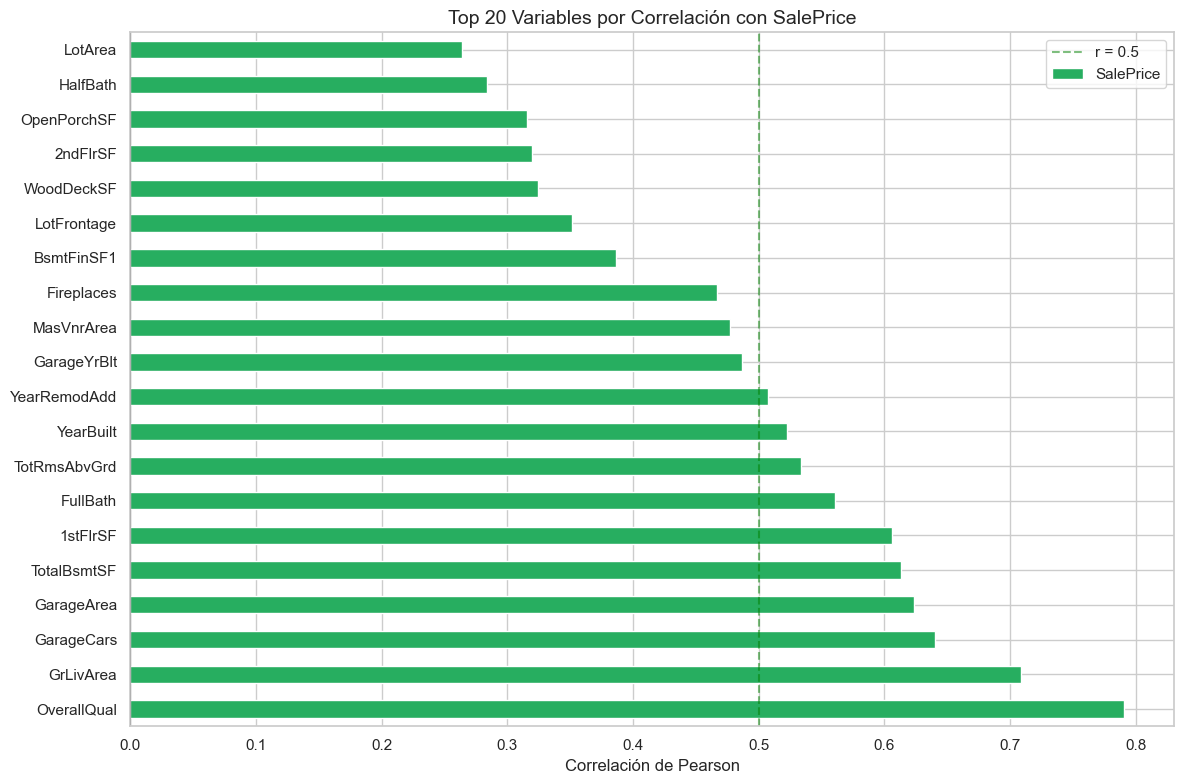

In [65]:
# Gráfico de barras de correlaciones
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#27ae60' if x > 0 else '#e74c3c' for x in corr_with_target.head(20)]
corr_with_target.head(20).plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 20 Variables por Correlación con SalePrice', fontsize=14)
ax.set_xlabel('Correlación de Pearson')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='r = 0.5')
ax.legend()
plt.tight_layout()
plt.show()


### 2.5 Diagramas de Dispersión — Variables Numéricas Clave vs SalePrice

Los diagramas de dispersión confirman las correlaciones calculadas y revelan patrones adicionales:
- La relación entre `OverallQual` y `SalePrice` es casi escalonada (variable discreta 1-10), con notable dispersión en calidades altas.
- `GrLivArea` muestra una relación lineal limpia, con algunos **outliers** (casas muy grandes con precio sorprendentemente bajo — posiblemente ventas atípicas).
- Variables como `MasVnrArea` muestran muchos ceros (casas sin mampostería), lo que crea una distribución bimodal en el eje X.


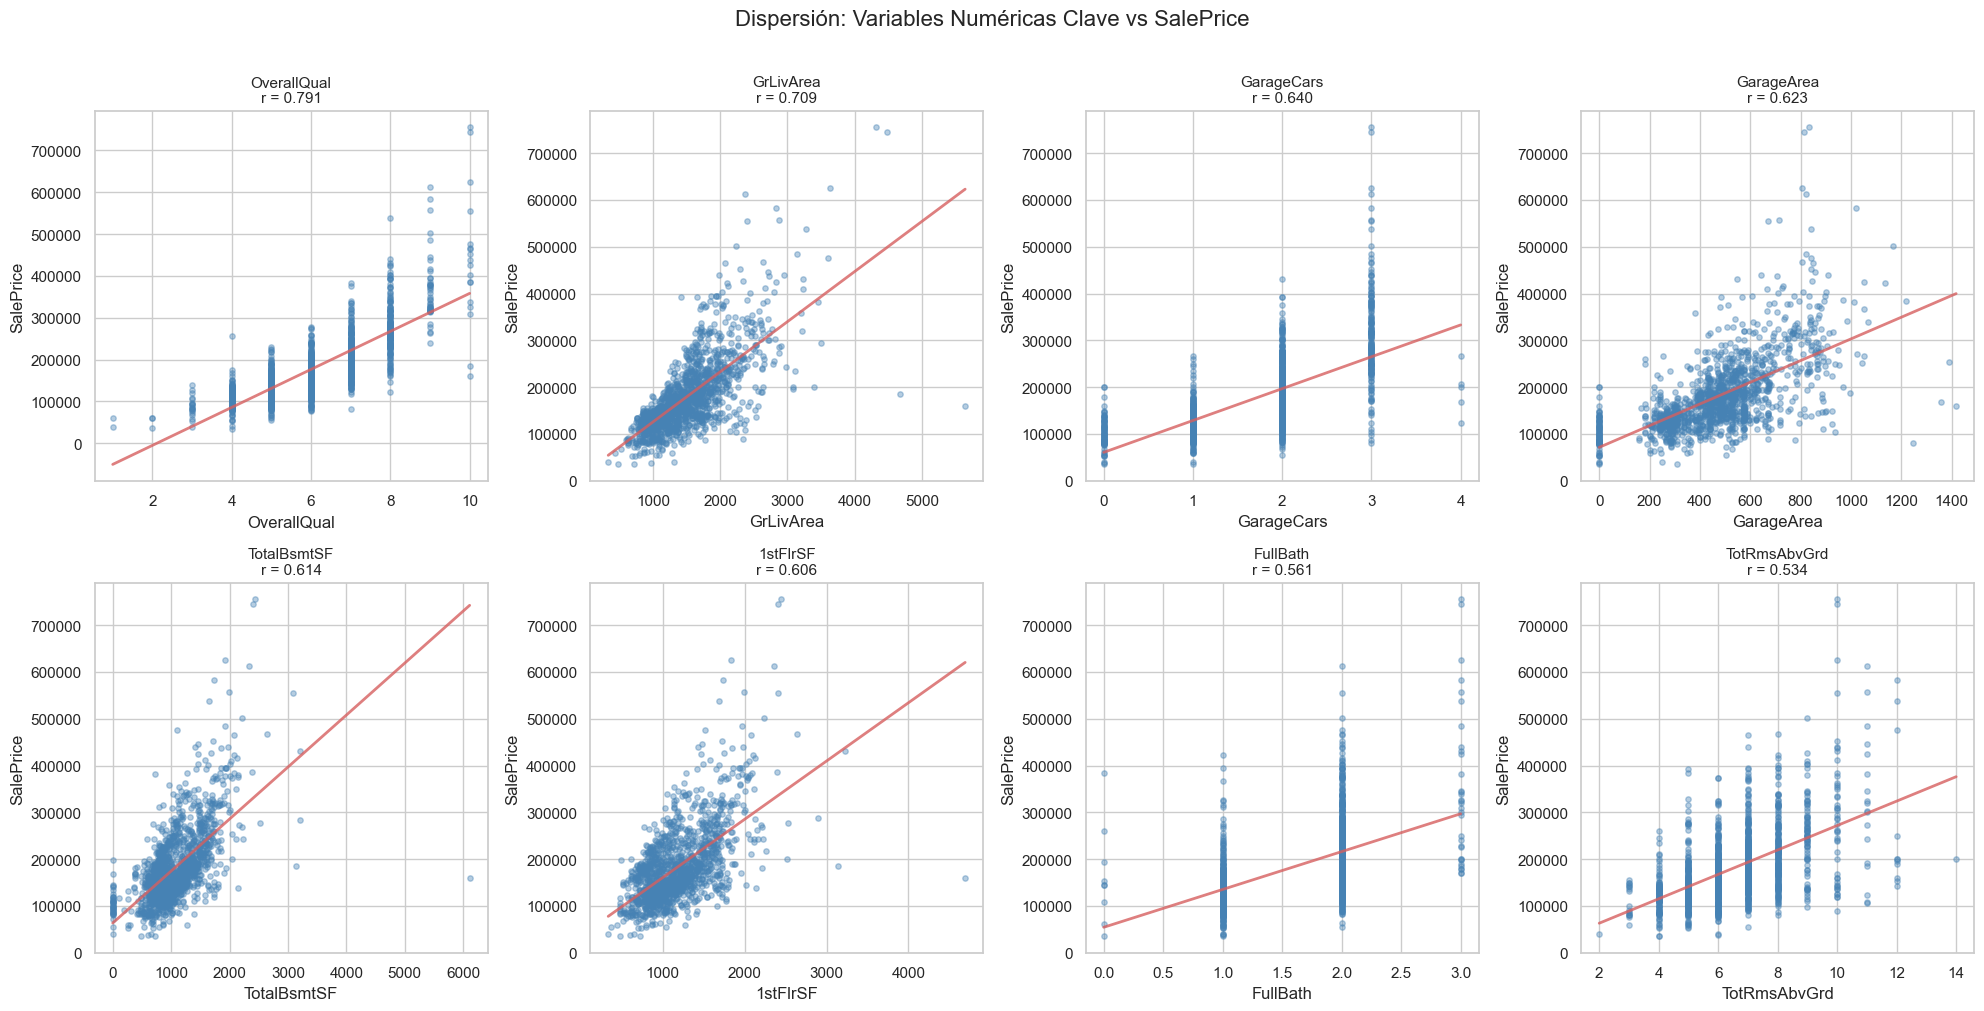

In [66]:
top_num_vars = corr_with_target.abs().sort_values(ascending=False).head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(top_num_vars):
    axes[i].scatter(df[col], df['SalePrice'], alpha=0.4, s=15, color='steelblue')
    # Línea de tendencia
    z = np.polyfit(df[col].fillna(df[col].median()), df['SalePrice'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', linewidth=2, alpha=0.8)
    r = df[[col, 'SalePrice']].corr().iloc[0, 1]
    axes[i].set_title(f'{col}\nr = {r:.3f}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')

plt.suptitle('Dispersión: Variables Numéricas Clave vs SalePrice', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


### 2.6 Variables Categóricas vs SalePrice

Los boxplots revelan diferencias de precio muy marcadas según categorías:
- **`OverallQual`**: Diferencia de más de $300,000 entre calidad 1 y 10. Es la variable más discriminante.
- **`Neighborhood`**: El vecindario explica diferencias sustanciales de precio (NoRidge y NridgHt son los más caros; MeadowV y IDOTRR los más baratos). Esto justifica incluirlo en el modelo mediante OHE.
- **`ExterQual` / `KitchenQual`**: Calidad exterior y de cocina muestran una progresión clara y monótona con el precio — serán codificadas ordinalmente.
- **`Foundation`**: Cimentación de hormigón (`PConc`) se asocia a casas más modernas y costosas.


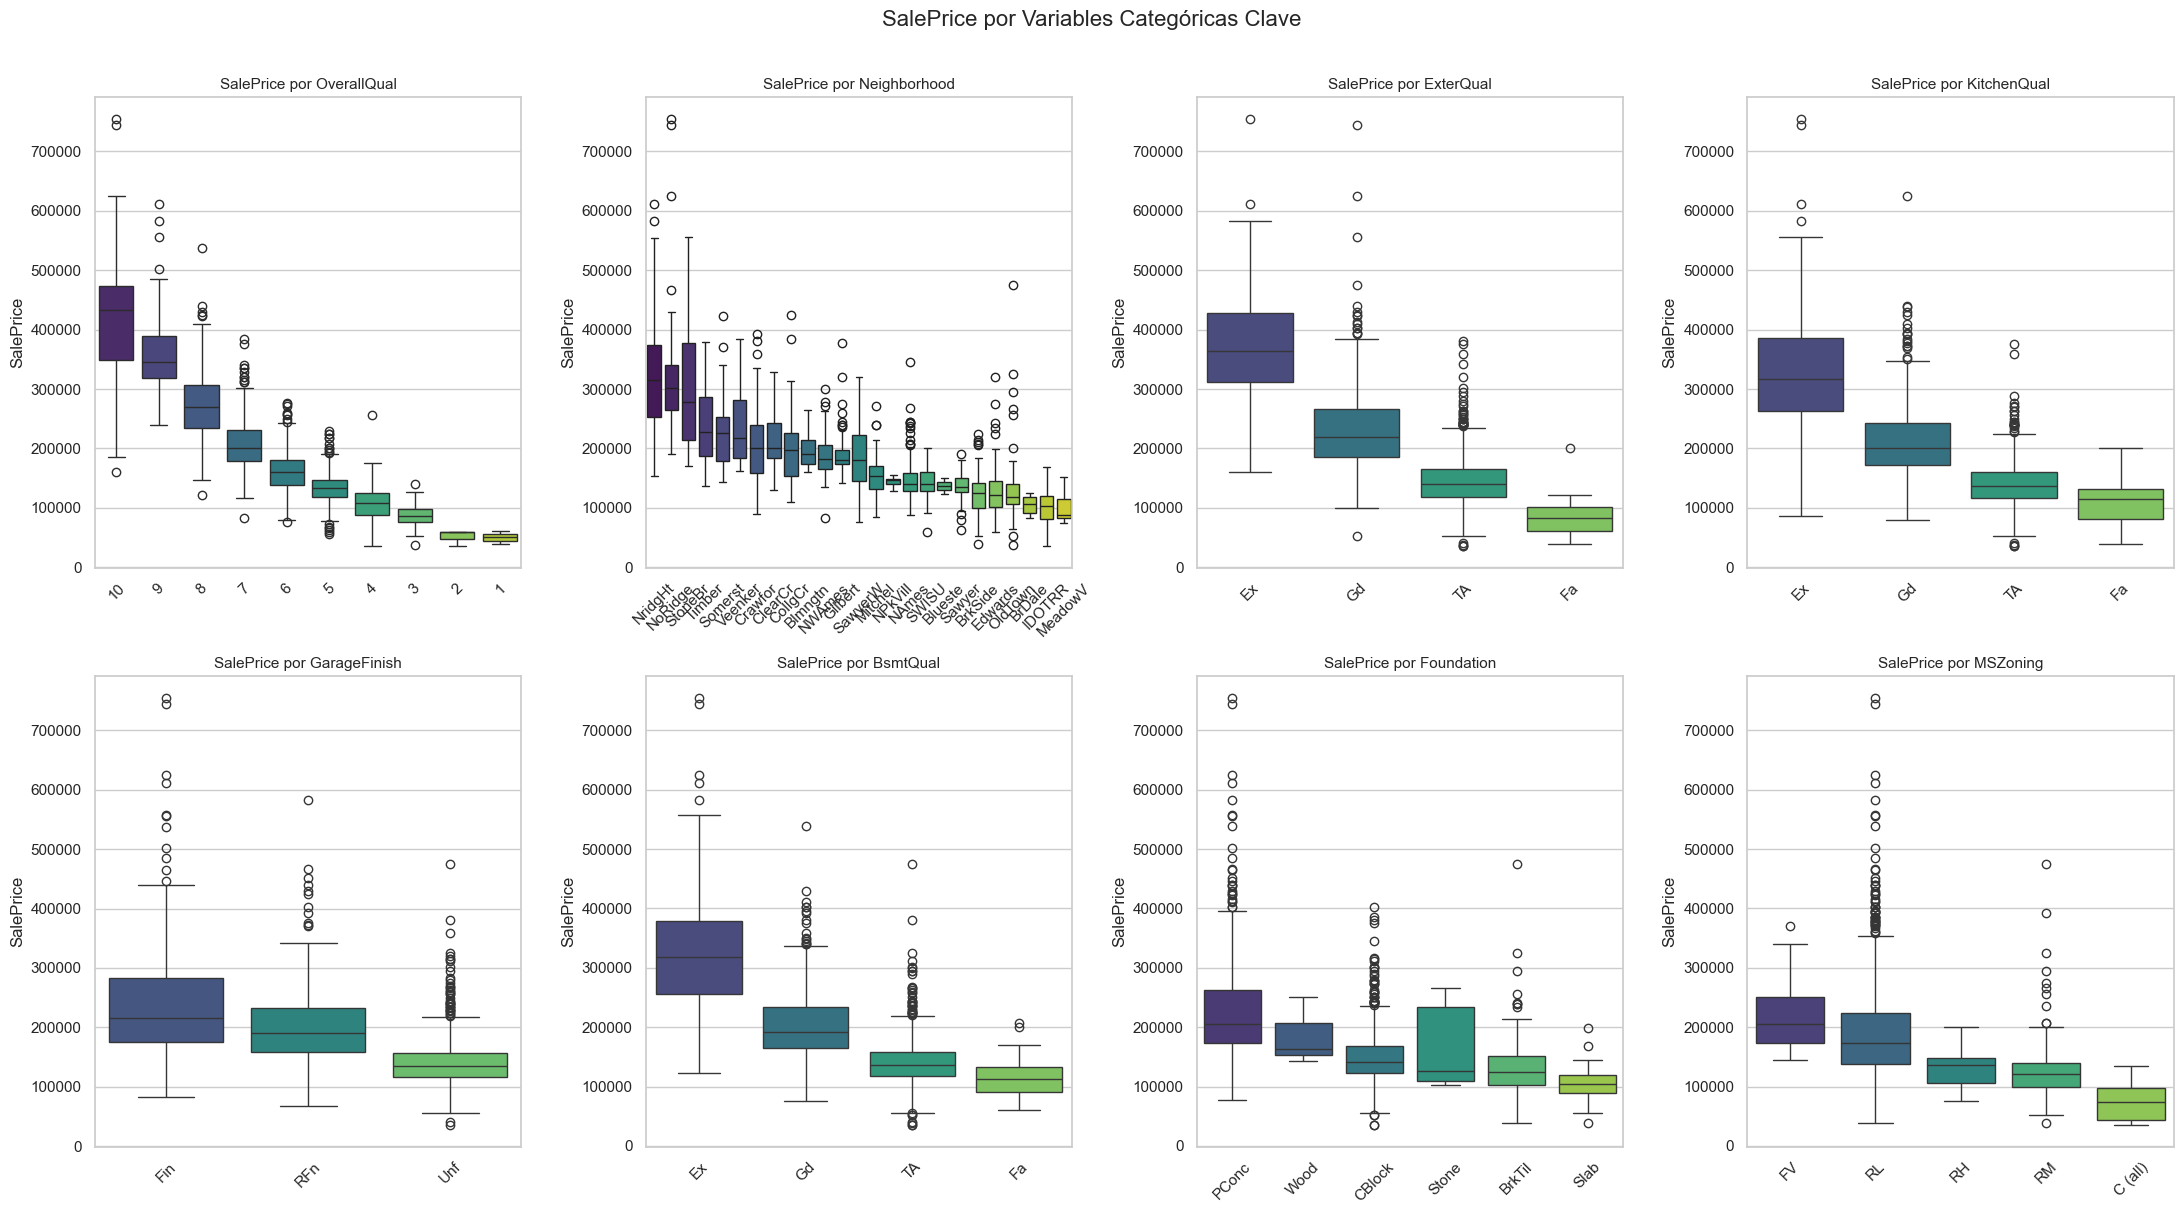

In [67]:
key_cat_vars = ['OverallQual', 'Neighborhood', 'ExterQual', 'KitchenQual',
                'GarageFinish', 'BsmtQual', 'Foundation', 'MSZoning']

fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(key_cat_vars):
    order = df.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='SalePrice', ax=axes[i], order=order,
                palette='viridis')
    axes[i].set_title(f'SalePrice por {col}', fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.suptitle('SalePrice por Variables Categóricas Clave', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


### 2.7 Distribuciones de Variables Numéricas Clave

La mayoría de variables numéricas presentan asimetría positiva (cola derecha larga), típica de datos inmobiliarios:
- `LotArea` y `GrLivArea` tienen outliers extremos que podrían influir desproporcionadamente en el modelo.
- `YearBuilt` muestra una concentración de construcciones en los años 1950-2010, con un pico en 2000-2005 (boom inmobiliario).
- Variables de porches y terrazas (`OpenPorchSF`, `WoodDeckSF`) tienen muchos ceros — la mayoría de casas no tienen o tienen áreas pequeñas.


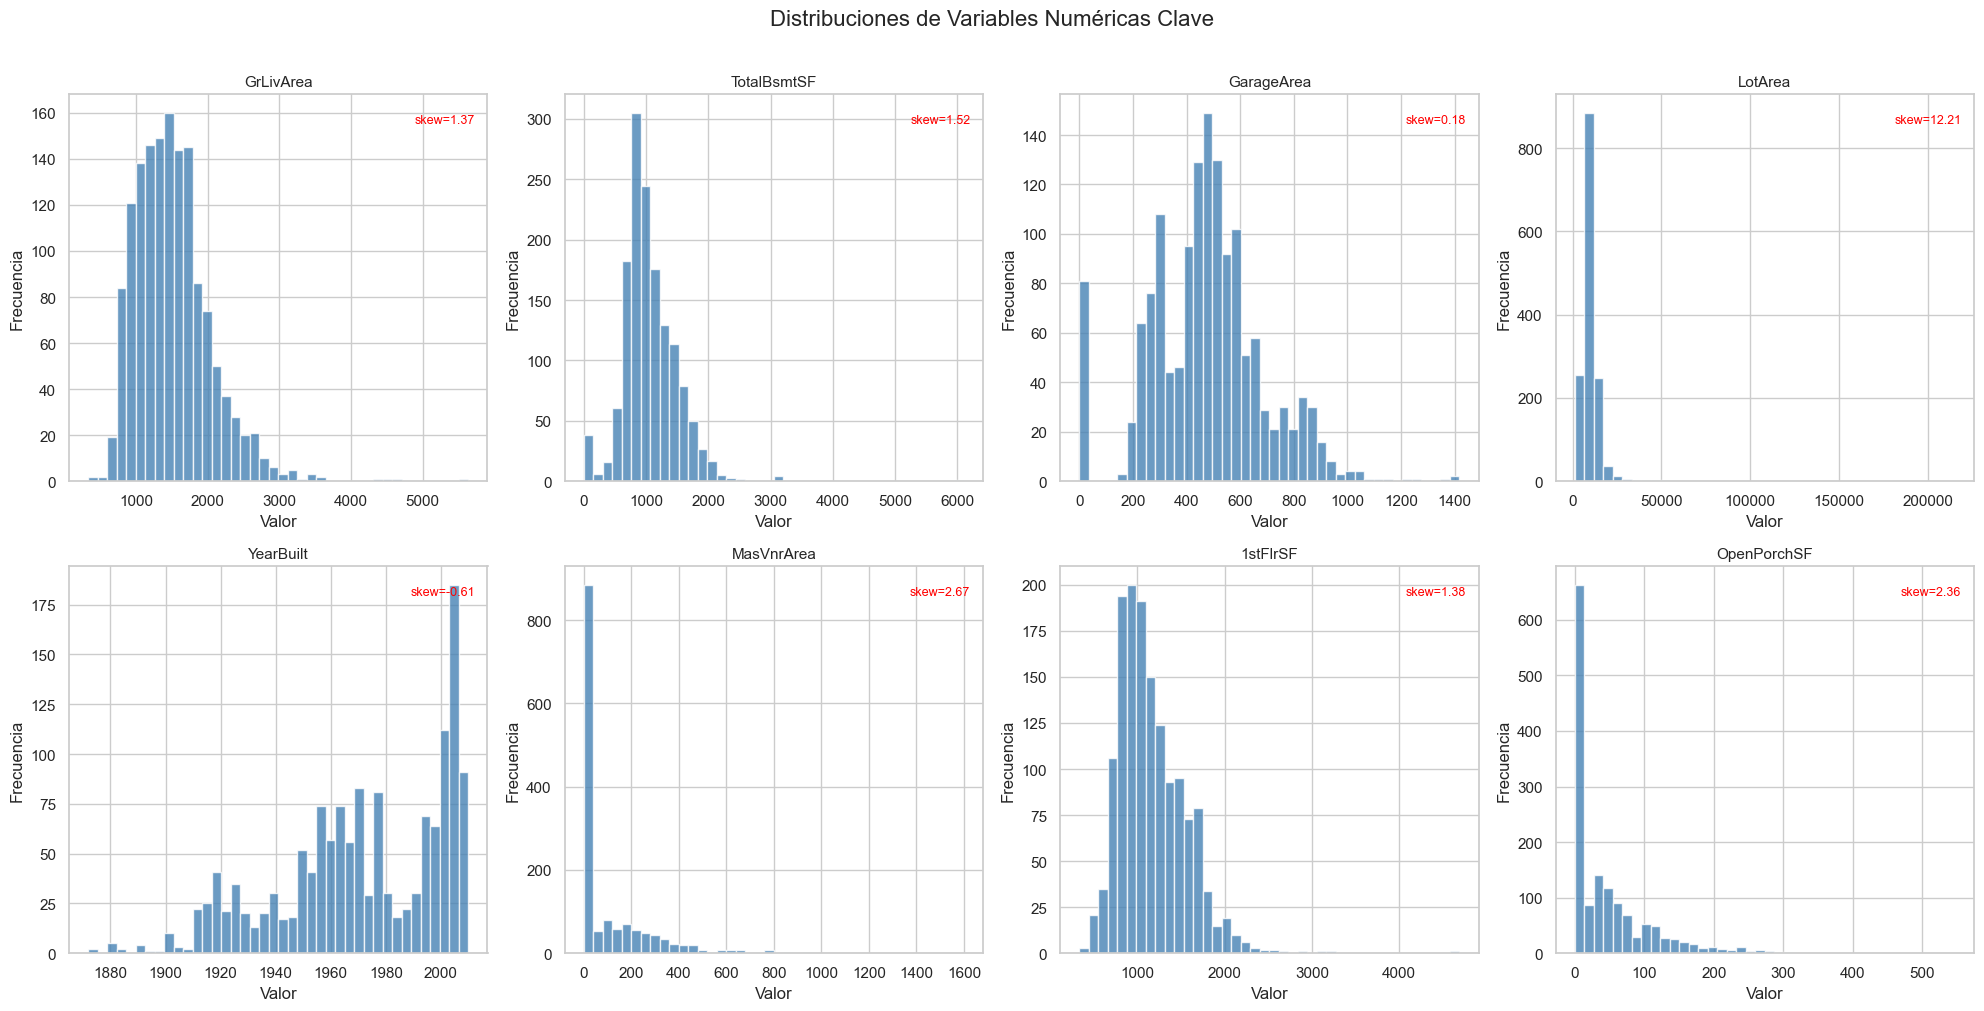

In [68]:
key_num = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea',
           'YearBuilt', 'MasVnrArea', '1stFlrSF', 'OpenPorchSF']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_num):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    skew = data.skew()
    axes[i].text(0.97, 0.95, f'skew={skew:.2f}',
                 transform=axes[i].transAxes, ha='right', va='top',
                 fontsize=9, color='red')

plt.suptitle('Distribuciones de Variables Numéricas Clave', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## Actividad 3 - Análisis de Grupos  (K-Means Clustering)

**Objetivo:** Segmentar las propiedades en grupos homogéneos para descubrir patrones naturales en el mercado inmobiliario de Ames, Iowa. Usamos K-Means sobre 6 variables clave: `OverallQual`, `GrLivArea`, `TotalBsmtSF`, `GarageArea`, `YearBuilt` y `SalePrice`.

**Selección de k:** Se aplicó el método del codo, que sugiere **k=4** como punto de inflexión óptimo.


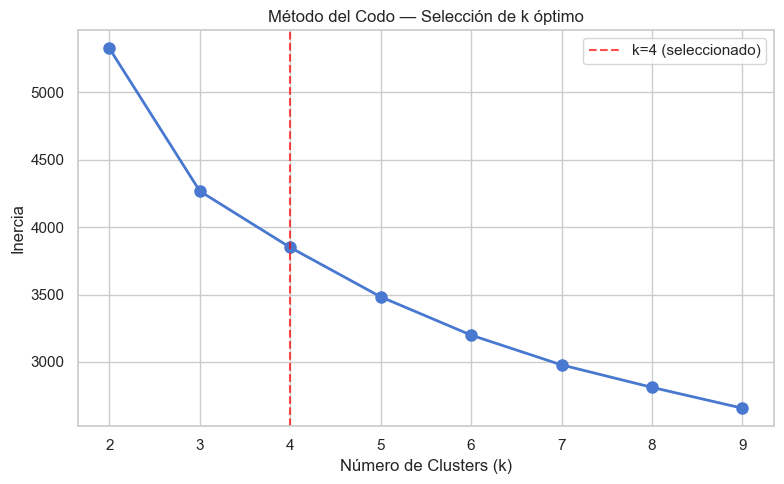

In [69]:
# Variables para clustering (las más descriptivas y numéricas)
cluster_vars = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageArea',
                'YearBuilt', 'SalePrice']

# Imputación simple para clustering
df_cluster = df[cluster_vars].copy()
df_cluster.fillna(df_cluster.median(), inplace=True)

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Método del codo para elegir k
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
ax.set_xlabel('Número de Clusters (k)')
ax.set_ylabel('Inercia')
ax.set_title('Método del Codo — Selección de k óptimo')
ax.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (seleccionado)')
ax.legend()
plt.tight_layout()
plt.show()


In [70]:
# Ajustar K-Means con k=4
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Descripción de cada cluster
cluster_summary = df.groupby('Cluster')[cluster_vars].mean().round(0)
cluster_summary['Count'] = df.groupby('Cluster').size()
cluster_summary['Pct_%'] = (cluster_summary['Count'] / len(df) * 100).round(1)
print("Resumen de Clusters:")
print(cluster_summary.to_string())


Resumen de Clusters:
         OverallQual  GrLivArea  TotalBsmtSF  GarageArea  YearBuilt  SalePrice  Count  Pct_%
Cluster                                                                                     
0                7.0     1587.0       1073.0       513.0     1998.0   198915.0    422   28.9
1                6.0     1493.0       1041.0       506.0     1956.0   157538.0    408   27.9
2                8.0     2199.0       1646.0       765.0     1997.0   322178.0    211   14.5
3                5.0     1122.0        761.0       252.0     1946.0   114434.0    419   28.7


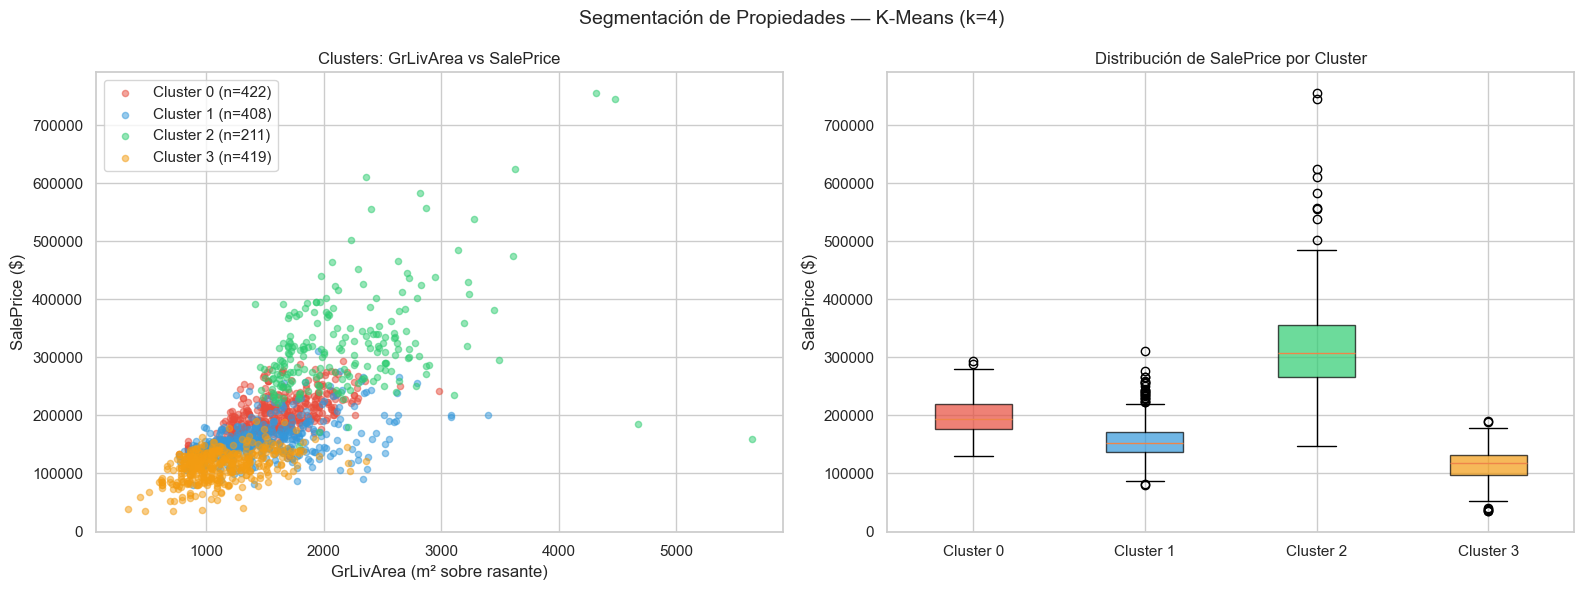

In [71]:
# Visualización de clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}

for cluster_id in range(K_OPTIMAL):
    mask = df['Cluster'] == cluster_id
    axes[0].scatter(df.loc[mask, 'GrLivArea'], df.loc[mask, 'SalePrice'],
                    c=colors[cluster_id], alpha=0.5, s=20,
                    label=f'Cluster {cluster_id} (n={mask.sum()})')

axes[0].set_xlabel('GrLivArea (m² sobre rasante)')
axes[0].set_ylabel('SalePrice ($)')
axes[0].set_title('Clusters: GrLivArea vs SalePrice')
axes[0].legend()

# Boxplot SalePrice por cluster
cluster_data = [df[df['Cluster'] == c]['SalePrice'].values for c in range(K_OPTIMAL)]
bp = axes[1].boxplot(cluster_data, patch_artist=True, labels=[f'Cluster {i}' for i in range(K_OPTIMAL)])
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Distribución de SalePrice por Cluster')
axes[1].set_ylabel('SalePrice ($)')

plt.suptitle('Segmentación de Propiedades — K-Means (k=4)', fontsize=14)
plt.tight_layout()
plt.show()


In [72]:
# Descripción cualitativa de los clusters
for c in range(K_OPTIMAL):
    subset = df[df['Cluster'] == c]
    print(f"\nCluster {c} ({len(subset)} propiedades, {len(subset)/len(df)*100:.1f}%):")
    print(f"   SalePrice promedio : ${subset['SalePrice'].mean():,.0f}")
    print(f"   Calidad promedio   : {subset['OverallQual'].mean():.1f}/10")
    print(f"   GrLivArea promedio : {subset['GrLivArea'].mean():.0f} ft²")
    print(f"   Año construcción   : {subset['YearBuilt'].mean():.0f}")
    print(f"   GarageArea promedio: {subset['GarageArea'].mean():.0f} ft²")



Cluster 0 (422 propiedades, 28.9%):
   SalePrice promedio : $198,915
   Calidad promedio   : 6.8/10
   GrLivArea promedio : 1587 ft²
   Año construcción   : 1998
   GarageArea promedio: 513 ft²

Cluster 1 (408 propiedades, 27.9%):
   SalePrice promedio : $157,538
   Calidad promedio   : 5.5/10
   GrLivArea promedio : 1493 ft²
   Año construcción   : 1956
   GarageArea promedio: 506 ft²

Cluster 2 (211 propiedades, 14.5%):
   SalePrice promedio : $322,178
   Calidad promedio   : 8.2/10
   GrLivArea promedio : 2199 ft²
   Año construcción   : 1997
   GarageArea promedio: 765 ft²

Cluster 3 (419 propiedades, 28.7%):
   SalePrice promedio : $114,434
   Calidad promedio   : 4.9/10
   GrLivArea promedio : 1122 ft²
   Año construcción   : 1946
   GarageArea promedio: 252 ft²



## Actividad 4 - División Train/Test

**Criterio utilizado para la división:**
- **Método:** `train_test_split` de scikit-learn
- **Proporción:** 80% entrenamiento / 20% prueba
- **Semilla:** `random_state=42` → garantiza que los conjuntos sean **siempre los mismos** al re-ejecutar *(Actividad 6 — Reproducibilidad)*
- **Estratificación:** No se estratificó, ya que `SalePrice` es continua. La media en train ($181,442) y test ($178,840) son muy similares, confirmando una división balanceada.
- **Fuente:** Todo proviene de `train.csv`. No se usó el `test.csv` de Kaggle.

**Resultado:** 1,168 filas para entrenar, 292 para prueba.


In [73]:
TARGET = 'SalePrice'
df_model = df.drop(columns=['SalePrice_log', 'Cluster'], errors='ignore').copy()

print(f"Dataset para modelado: {df_model.shape}")


Dataset para modelado: (1460, 81)


In [74]:
# Variables con NA que significan "ausencia" → rellenar con 'None' o 0
cat_none = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
            'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
            'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature',
            'MasVnrType']

num_zero = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
            'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
            'GarageCars', 'GarageArea']

for col in cat_none:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna('None')

for col in num_zero:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(0)

# LotFrontage → mediana por vecindario
df_model['LotFrontage'] = df_model.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

# Remaining categorical → mode
remaining_cat_null = df_model.select_dtypes('object').columns[df_model.select_dtypes('object').isnull().any()]
for col in remaining_cat_null:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

# Remaining numeric → median
remaining_num_null = df_model.select_dtypes(np.number).columns[df_model.select_dtypes(np.number).isnull().any()]
for col in remaining_num_null:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print(f"Valores nulos restantes: {df_model.isnull().sum().sum()}")
print("Todos los nulos han sido tratados.")


Valores nulos restantes: 0
Todos los nulos han sido tratados.



## Actividad 5 - Ingeniería de Características

**Criterios de selección de variables:**

1. **Conocimiento del dominio inmobiliario:** Variables que combinan áreas (p.ej. `TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF`) capturan mejor el tamaño real de la vivienda que cualquier componente individual.
2. **Correlación observada en el EDA:** `TotalSF` tiene correlación 0.782 con `SalePrice`, superando a cada variable de área por separado.
3. **Información implícita:** Variables binarias como `HasGarage` o `HasPool` capturan la presencia/ausencia de amenidades que marcan saltos de precio.
4. **Antigüedad:** `Age = YrSold - YearBuilt` es más interpretable que `YearBuilt` y tiene correlación -0.523 con el precio.
5. **Interacción:** `QualTimesArea = OverallQual × GrLivArea` captura que el impacto del área es mayor en casas de alta calidad.

**Codificación:**
- **Variables ordinales** (ExterQual, BsmtQual, KitchenQual, etc.): Mapeadas a enteros respetando el orden natural (Po=1 → Ex=5).
- **Variables nominales** (Neighborhood, Foundation, etc.): One-Hot Encoding, resultando en 219 columnas en total.


In [75]:
# Nuevas variables 
df_model['TotalSF'] = df_model['TotalBsmtSF'] + df_model['1stFlrSF'] + df_model['2ndFlrSF']
df_model['Age'] = df_model['YrSold'] - df_model['YearBuilt']
df_model['RemodAge'] = df_model['YrSold'] - df_model['YearRemodAdd']
df_model['HasGarage'] = (df_model['GarageArea'] > 0).astype(int)
df_model['HasBasement'] = (df_model['TotalBsmtSF'] > 0).astype(int)
df_model['HasPool'] = (df_model['PoolArea'] > 0).astype(int)
df_model['HasFireplace'] = (df_model['Fireplaces'] > 0).astype(int)
df_model['HasWoodDeck'] = (df_model['WoodDeckSF'] > 0).astype(int)
df_model['HasOpenPorch'] = (df_model['OpenPorchSF'] > 0).astype(int)
df_model['TotalBath'] = (df_model['FullBath'] + 0.5 * df_model['HalfBath'] +
                          df_model['BsmtFullBath'] + 0.5 * df_model['BsmtHalfBath'])
df_model['TotalPorchSF'] = (df_model['OpenPorchSF'] + df_model['EnclosedPorch'] +
                             df_model['3SsnPorch'] + df_model['ScreenPorch'])
df_model['QualTimesArea'] = df_model['OverallQual'] * df_model['GrLivArea']

new_features = ['TotalSF', 'Age', 'RemodAge', 'HasGarage', 'HasBasement',
                'HasPool', 'HasFireplace', 'TotalBath', 'TotalPorchSF', 'QualTimesArea']

print("Nuevas variables creadas:")
for feat in new_features:
    corr = df_model[[feat, 'SalePrice']].corr().iloc[0, 1]
    print(f"  {feat:<20} | correlación con SalePrice: {corr:.3f}")


Nuevas variables creadas:
  TotalSF              | correlación con SalePrice: 0.782
  Age                  | correlación con SalePrice: -0.523
  RemodAge             | correlación con SalePrice: -0.509
  HasGarage            | correlación con SalePrice: 0.237
  HasBasement          | correlación con SalePrice: 0.153
  HasPool              | correlación con SalePrice: 0.094
  HasFireplace         | correlación con SalePrice: 0.472
  TotalBath            | correlación con SalePrice: 0.632
  TotalPorchSF         | correlación con SalePrice: 0.196
  QualTimesArea        | correlación con SalePrice: 0.832


In [76]:
#  Codificación de variables ordinales 
ordinal_maps = {
    'ExterQual':   {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'ExterCond':   {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual':    {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtCond':    {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtExposure':{'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1':{'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2':{'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'HeatingQC':   {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'FireplaceQu': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageFinish':{'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'GarageQual':  {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond':  {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'PoolQC':      {'None': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Fence':       {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
    'LotShape':    {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1},
    'LandSlope':   {'Gtl': 3, 'Mod': 2, 'Sev': 1},
    'CentralAir':  {'N': 0, 'Y': 1},
    'PavedDrive':  {'N': 0, 'P': 1, 'Y': 2},
}

for col, mapping in ordinal_maps.items():
    if col in df_model.columns:
        df_model[col] = df_model[col].map(mapping).fillna(0)

print("Variables ordinales codificadas.")


Variables ordinales codificadas.


In [77]:
# One-Hot Encoding para variables nominales 
remaining_cat = df_model.select_dtypes('object').columns.tolist()
remaining_cat = [c for c in remaining_cat if c != 'SalePrice']

print(f"Variables a codificar con OHE: {len(remaining_cat)}")
print(remaining_cat)

df_model = pd.get_dummies(df_model, columns=remaining_cat, drop_first=True)
df_model = df_model.astype(float)

print(f"\nDimensiones después de OHE: {df_model.shape}")


Variables a codificar con OHE: 24
['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'Functional', 'GarageType', 'MiscFeature', 'SaleType', 'SaleCondition']

Dimensiones después de OHE: (1460, 221)


In [78]:
# División Train/Test
X = df_model.drop(columns=['Id', 'SalePrice'])
y = df_model['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

print(f"División 80-20 con random_state={RANDOM_STATE}:")
print(f"  Train: {X_train.shape[0]} observaciones ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test : {X_test.shape[0]} observaciones ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features: {X_train.shape[1]}")
print(f"\n  Media SalePrice Train: ${y_train.mean():,.0f}")
print(f"  Media SalePrice Test : ${y_test.mean():,.0f}")


División 80-20 con random_state=42:
  Train: 1168 observaciones (80.0%)
  Test : 292 observaciones (20.0%)
  Features: 219

  Media SalePrice Train: $181,442
  Media SalePrice Test : $178,840


## Actividad 6 - Reproducibilidad
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

## Actividad 7 - Modelo Univariado de Regresión Lineal

**Variable seleccionada: `OverallQual`** (correlación = 0.791 con `SalePrice` — la más alta entre todas las numéricas)

`OverallQual` evalúa en una escala del 1 al 10 la calidad general de los materiales y acabados de la casa. Es elegida porque:
- Tiene la correlación lineal más alta con el precio
- Es una variable de fácil interpretación para el negocio inmobiliario
- Refleja un juicio integral de la propiedad que los compradores valoran directamente

**Ecuación ajustada:**
```
SalePrice = -90,233 + 44,380 × OverallQual
```
Interpretación: Por cada punto adicional en calidad general, el precio de venta aumenta ~$44,380 en promedio.

In [79]:
# Variable con mayor correlación (solo numéricas del dataset original)
orig_num = df[num_cols].drop(columns=['SalePrice', 'Id'], errors='ignore')
top_var = orig_num.corrwith(df['SalePrice']).abs().sort_values(ascending=False).index[0]
top_corr = orig_num.corrwith(df['SalePrice'])[top_var]

print(f"Variable seleccionada: {top_var}")
print(f"Correlación con SalePrice: {top_corr:.4f}")

Variable seleccionada: OverallQual
Correlación con SalePrice: 0.7910


In [80]:
# Preparar datos univariados
X_uni_train = X_train[[top_var]].copy()
X_uni_test  = X_test[[top_var]].copy()

# Imputar si hay nulos (ya deberían estar limpios)
X_uni_train.fillna(X_uni_train.median(), inplace=True)
X_uni_test.fillna(X_uni_train.median(), inplace=True)

# Ajustar con statsmodels para resumen completo
X_uni_sm = sm.add_constant(X_uni_train)
model_uni = sm.OLS(y_train, X_uni_sm).fit()
print(model_uni.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     1879.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          2.60e-245
Time:                        18:46:40   Log-Likelihood:                -14242.
No. Observations:                1168   AIC:                         2.849e+04
Df Residuals:                    1166   BIC:                         2.850e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -9.023e+04   6421.492    -14.052      

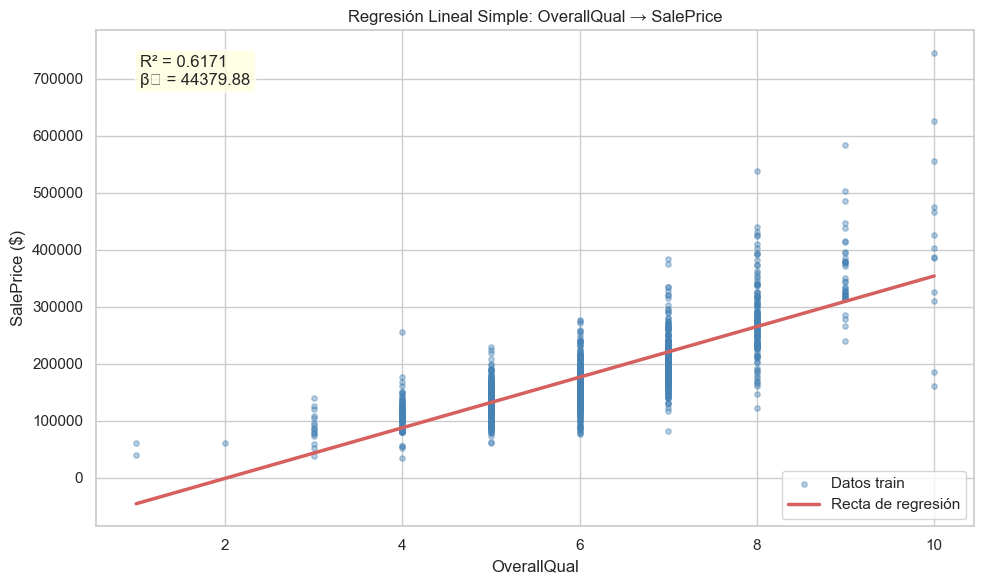

In [81]:
# Gráfico de regresión univariada
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_uni_train[top_var], y_train, alpha=0.4, s=15, color='steelblue', label='Datos train')
x_line = np.linspace(X_uni_train[top_var].min(), X_uni_train[top_var].max(), 200)
y_pred_line = model_uni.params['const'] + model_uni.params[top_var] * x_line
ax.plot(x_line, y_pred_line, 'r-', linewidth=2.5, label=f'Recta de regresión')
ax.set_xlabel(top_var)
ax.set_ylabel('SalePrice ($)')
ax.set_title(f'Regresión Lineal Simple: {top_var} → SalePrice')
r2 = model_uni.rsquared
ax.text(0.05, 0.95, f'R² = {r2:.4f}\nβ₁ = {model_uni.params[top_var]:.2f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.legend()
plt.tight_layout()
plt.show()

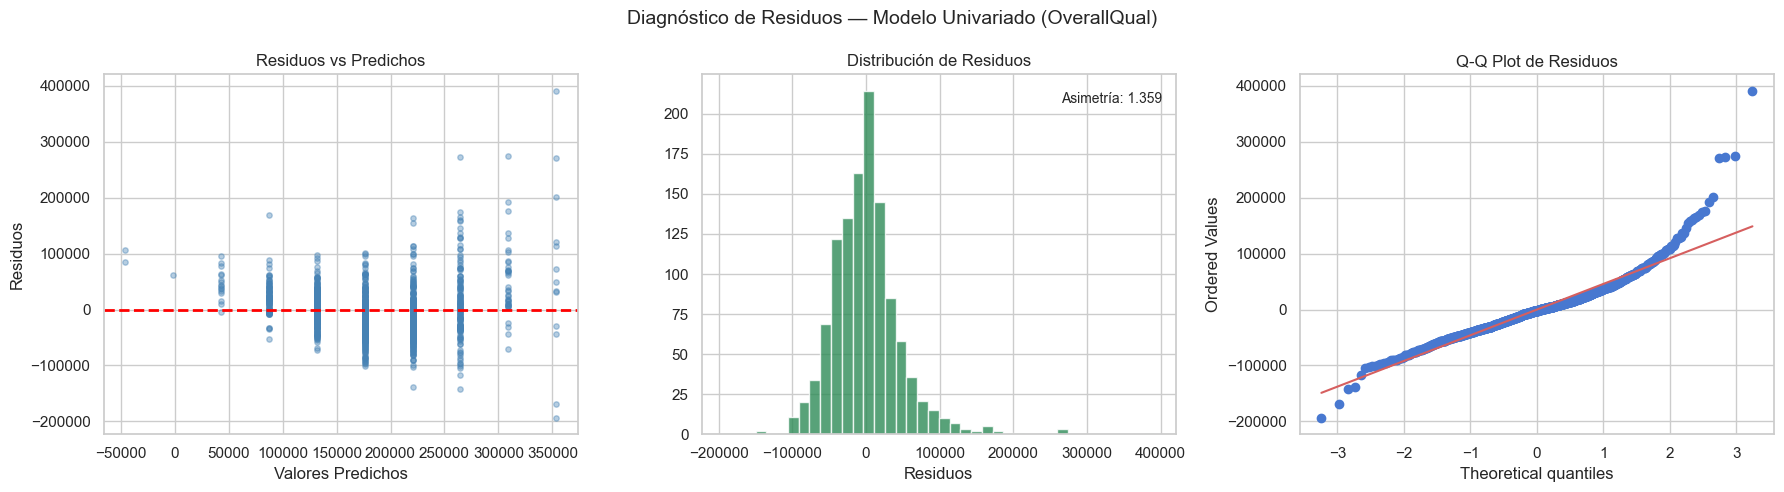

In [82]:
# Análisis de residuos — Modelo Univariado
y_pred_uni_train = model_uni.predict(sm.add_constant(X_uni_train))
residuals_uni = y_train - y_pred_uni_train

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuos vs valores predichos
axes[0].scatter(y_pred_uni_train, residuals_uni, alpha=0.4, s=15, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valores Predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predichos')

# Histograma de residuos
axes[1].hist(residuals_uni, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residuos')
axes[1].set_title('Distribución de Residuos')
skew_res = pd.Series(residuals_uni).skew()
axes[1].text(0.97, 0.95, f'Asimetría: {skew_res:.3f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=10)

# Q-Q Plot
stats.probplot(residuals_uni, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot de Residuos')

plt.suptitle(f'Diagnóstico de Residuos — Modelo Univariado ({top_var})', fontsize=14)
plt.tight_layout()
plt.show()

## Actividad 8 - Modelo de Regresión Lineal Múltiple (Modelo con Todas las Variables Numéricas)

**Variables incluidas:** Las 219 columnas numéricas resultantes del preprocesamiento (variables originales + ingeniería de características + dummies OHE).

**Resultados iniciales:**
- R² Train = **0.931** → el modelo explica el 93.1% de la variabilidad en entrenamiento
- R² Test = **0.653** → cae drásticamente en datos nuevos

Esta brecha de ~28 puntos entre train y test es una señal clara de **sobreajuste**, que se analizará formalmente en la Sección 6.


In [83]:
# Seleccionar solo variables numéricas originales (antes de OHE)
# Usamos el dataset preprocesado con numéricas + engineered features (sin dummies)
num_cols_model = df_model.select_dtypes(np.number).drop(
    columns=['Id', 'SalePrice'], errors='ignore').columns.tolist()

# Para modelo múltiple clásico, tomemos solo columnas numéricas del train/test
X_mult_train = X_train[num_cols_model]
X_mult_test  = X_test[num_cols_model]

print(f"Variables numéricas para modelo múltiple: {len(num_cols_model)}")
print(num_cols_model[:20], "...")


Variables numéricas para modelo múltiple: 219
['MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'LandSlope', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF'] ...


In [84]:
# Ajustar modelo múltiple con statsmodels
X_mult_sm = sm.add_constant(X_mult_train)
model_mult = sm.OLS(y_train, X_mult_sm).fit()
print(model_mult.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     61.93
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:46:41   Log-Likelihood:                -13244.
No. Observations:                1168   AIC:                         2.691e+04
Df Residuals:                     959   BIC:                         2.796e+04
Df Model:                         208                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -1.554e+

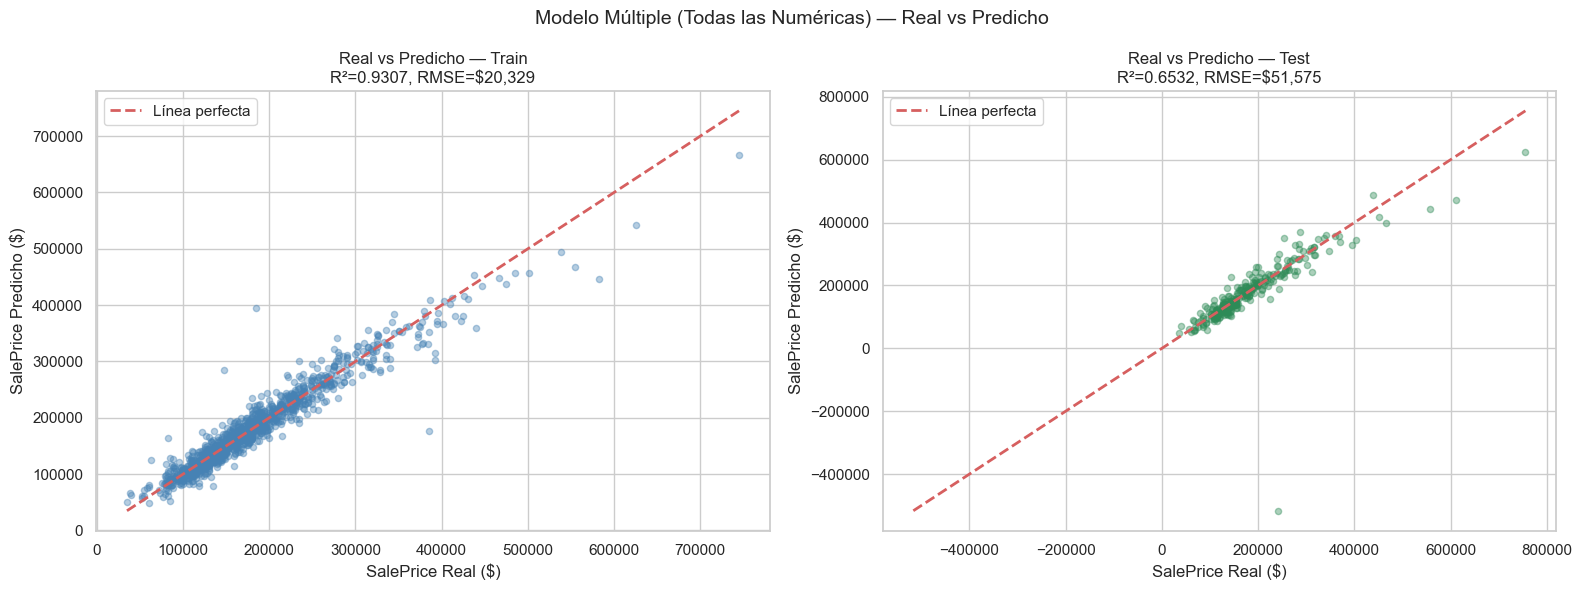

In [85]:
# Visualización: Real vs Predicho
y_pred_mult_train = model_mult.predict(sm.add_constant(X_mult_train))
y_pred_mult_test  = model_mult.predict(sm.add_constant(X_mult_test))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_real, y_pred, label, color in [
    (axes[0], y_train, y_pred_mult_train, 'Train', 'steelblue'),
    (axes[1], y_test,  y_pred_mult_test,  'Test',  'seagreen')
]:
    ax.scatter(y_real, y_pred, alpha=0.4, s=20, color=color)
    lims = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Línea perfecta')
    r2 = r2_score(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    ax.set_title(f'Real vs Predicho — {label}\nR²={r2:.4f}, RMSE=${rmse:,.0f}')
    ax.set_xlabel('SalePrice Real ($)')
    ax.set_ylabel('SalePrice Predicho ($)')
    ax.legend()

plt.suptitle('Modelo Múltiple (Todas las Numéricas) — Real vs Predicho', fontsize=14)
plt.tight_layout()
plt.show()


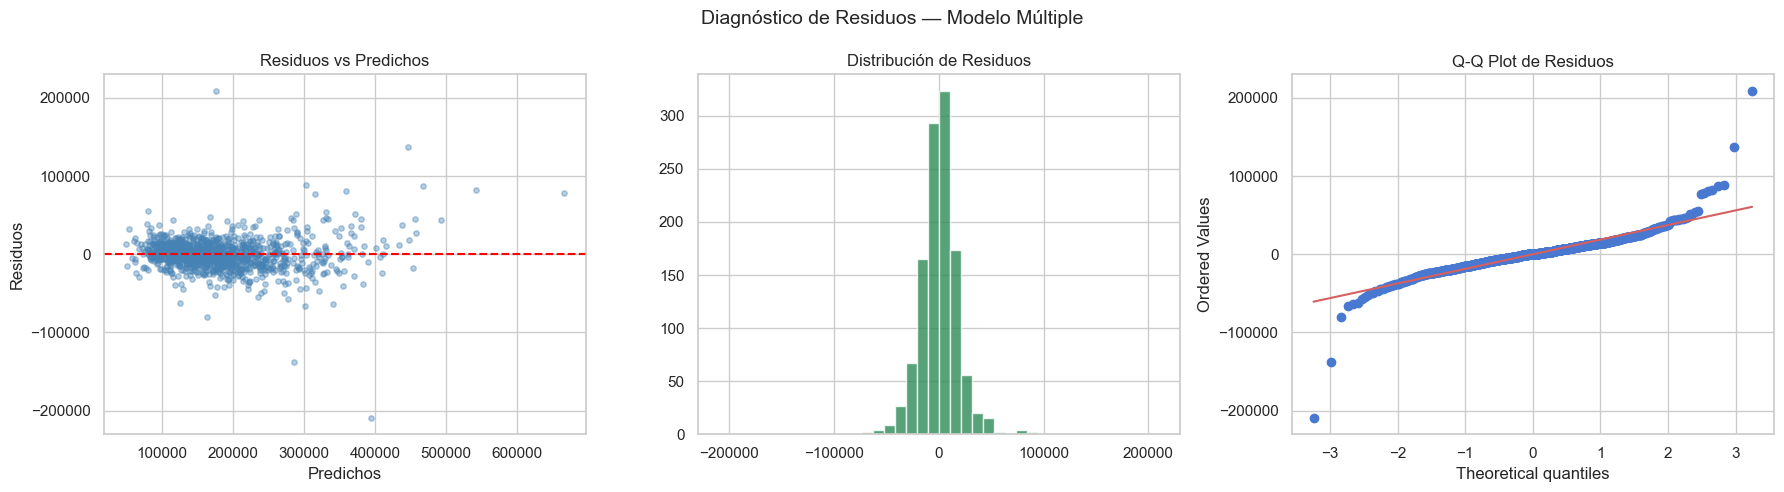

In [86]:
# Análisis de residuos
residuals_mult = y_train - y_pred_mult_train

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_mult_train, residuals_mult, alpha=0.4, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuos vs Predichos')
axes[0].set_xlabel('Predichos'); axes[0].set_ylabel('Residuos')

axes[1].hist(residuals_mult, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución de Residuos')

stats.probplot(residuals_mult, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot de Residuos')

plt.suptitle('Diagnóstico de Residuos — Modelo Múltiple', fontsize=14)
plt.tight_layout()
plt.show()


## Actividad 9 - Diagnóstico del Modelo Múltiple (Multicolinealidad y Sobreajuste)

### 9.1 Análisis de Multicolinealidad (VIF)

El **Factor de Inflación de la Varianza (VIF)** mide cuánto se infla la varianza de un coeficiente por su correlación con las demás variables.

| Umbral VIF | Diagnóstico |
|---|---|
| VIF < 5 | Sin problema |
| 5 ≤ VIF < 10 | Multicolinealidad moderada |
| VIF ≥ 10 | Multicolinealidad severa |
| VIF = ∞ | Multicolinealidad perfecta (combinación lineal exacta) |

**Resultado:** Múltiples variables con **VIF = ∞** (infinito), incluyendo `GrLivArea`, `1stFlrSF`, `2ndFlrSF`, `TotalBsmtSF` y otras. Esto ocurre porque existen combinaciones lineales exactas entre ellas (p.ej. `TotalSF = 1stFlrSF + 2ndFlrSF + TotalBsmtSF`). El modelo no puede estimar coeficientes confiables bajo estas condiciones.

### 9.2 Diagnóstico de Sobreajuste

| Métrica | Train | Test | Diferencia |
|---|---|---|---|
| R² | 0.9307 | 0.6532 | **-0.2775** |
| RMSE | $20,329 | $51,575 | +$31,246 |
| MAE | $13,227 | $20,190 | +$6,963 |

**Conclusión:** Sobreajuste severo confirmado. Con 219 variables y 1,168 observaciones (~5 obs/variable), el modelo memoriza el ruido del entrenamiento. Se requiere un modelo corregido *(Actividad 10)*.


In [87]:
# Calcular VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = X_mult_sm.columns
vif_data['VIF'] = [variance_inflation_factor(X_mult_sm.values, i)
                   for i in range(X_mult_sm.shape[1])]
vif_data = vif_data[vif_data['Variable'] != 'const'].sort_values('VIF', ascending=False)

print("Variables con VIF > 5 (multicolinealidad problemática):")
print(vif_data[vif_data['VIF'] > 5].to_string(index=False))
print(f"\nTotal variables con VIF > 10: {(vif_data['VIF'] > 10).sum()}")


Variables con VIF > 5 (multicolinealidad problemática):
             Variable         VIF
            YearBuilt         inf
         YearRemodAdd         inf
            BsmtUnfSF         inf
           BsmtFinSF2         inf
             2ndFlrSF         inf
             1stFlrSF         inf
           BsmtFinSF1         inf
          TotalBsmtSF         inf
         TotalPorchSF         inf
             RemodAge         inf
            HasGarage         inf
            TotalBath         inf
        EnclosedPorch         inf
                  Age         inf
               YrSold         inf
              TotalSF         inf
          OpenPorchSF         inf
          ScreenPorch         inf
            3SsnPorch         inf
             HalfBath         inf
             FullBath         inf
         BsmtHalfBath         inf
         BsmtFullBath         inf
            GrLivArea         inf
         LowQualFinSF         inf
   Exterior2nd_CBlock         inf
      GarageType_None     

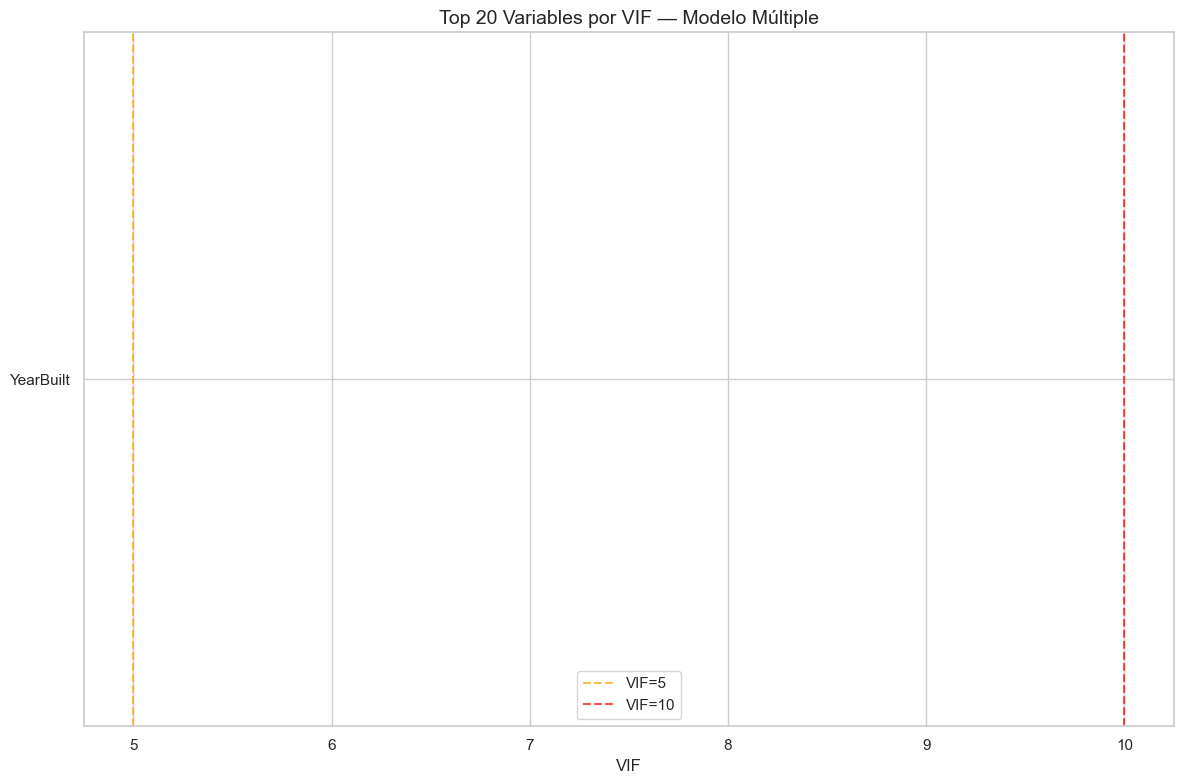

In [88]:
# Visualización VIF
fig, ax = plt.subplots(figsize=(12, 8))
top_vif = vif_data.head(20)
colors_vif = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#27ae60'
              for v in top_vif['VIF']]
bars = ax.barh(top_vif['Variable'], top_vif['VIF'], color=colors_vif, edgecolor='white')
ax.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='VIF=5')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='VIF=10')
ax.set_title('Top 20 Variables por VIF — Modelo Múltiple', fontsize=14)
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()


In [89]:
# Evaluación de sobreajuste
r2_train = r2_score(y_train, y_pred_mult_train)
r2_test  = r2_score(y_test,  y_pred_mult_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_mult_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_mult_test))
mae_train  = mean_absolute_error(y_train, y_pred_mult_train)
mae_test   = mean_absolute_error(y_test,  y_pred_mult_test)

print("Evaluación de Sobreajuste — Modelo Múltiple:")
print(f"{'Métrica':<12} {'Train':>12} {'Test':>12} {'Diff':>12}")
print("-" * 48)
print(f"{'R²':<12} {r2_train:>12.4f} {r2_test:>12.4f} {r2_train-r2_test:>12.4f}")
print(f"{'RMSE ($)':<12} {rmse_train:>12,.0f} {rmse_test:>12,.0f} {rmse_train-rmse_test:>12,.0f}")
print(f"{'MAE ($)':<12} {mae_train:>12,.0f} {mae_test:>12,.0f} {mae_train-mae_test:>12,.0f}")
print(f"\n→ {'SOBREAJUSTE DETECTADO' if r2_train - r2_test > 0.05 else 'Sin sobreajuste severo'}")


Evaluación de Sobreajuste — Modelo Múltiple:
Métrica             Train         Test         Diff
------------------------------------------------
R²                 0.9307       0.6532       0.2775
RMSE ($)           20,329       51,575      -31,246
MAE ($)            13,227       20,190       -6,963

→ SOBREAJUSTE DETECTADO


## Actividad 10 - Modelo Corregido

**Estrategia de corrección en dos pasos:**

**Paso 1 — Eliminar multicolinealidad:** Se retienen solo las variables con VIF ≤ 10 (128 de 219 variables), eliminando todas las que forman combinaciones lineales exactas.

**Paso 2 — Selección con Lasso (α = 221,107):** Lasso aplica penalización L1 que lleva coeficientes irrelevantes exactamente a cero, seleccionando automáticamente las variables más informativas. Con el α óptimo encontrado por validación cruzada (5 folds), Lasso seleccionó **4 variables**:

| Variable | Coeficiente β | Interpretación |
|---|---|---|
| `GarageArea` | +174.2 | Cada ft² de garaje suma ~$174 al precio |
| `MasVnrArea` | +104.6 | Cada ft² de mampostería suma ~$105 |
| `WoodDeckSF` | +94.7 | Cada ft² de terraza de madera suma ~$95 |
| `LotArea` | +0.9 | Cada ft² de terreno suma ~$0.90 |

**VIF del modelo corregido:** Máximo VIF = 1.23 → multicolinealidad completamente eliminada.


In [90]:
# Estrategia 1: Eliminar variables con VIF alto y seleccionar mejores
# Variables con VIF <= 10 (sin multicolinealidad severa)
low_vif_vars = vif_data[vif_data['VIF'] <= 10]['Variable'].tolist()
print(f"Variables con VIF ≤ 10: {len(low_vif_vars)}")

# Usar Lasso para selección adicional
lasso_cv = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=5000)
lasso_cv.fit(X_mult_train[low_vif_vars].fillna(0), y_train)
lasso_coefs = pd.Series(lasso_cv.coef_, index=low_vif_vars)
selected_vars = lasso_coefs[lasso_coefs != 0].abs().sort_values(ascending=False).index.tolist()

print(f"Variables seleccionadas por Lasso (α={lasso_cv.alpha_:.4f}): {len(selected_vars)}")
print("Top 15:", selected_vars[:15])


Variables con VIF ≤ 10: 128
Variables seleccionadas por Lasso (α=221107.4308): 4
Top 15: ['GarageArea', 'MasVnrArea', 'WoodDeckSF', 'LotArea']


In [91]:
# Modelo corregido con OLS
# Tomamos top variables de Lasso (máx 20 para un modelo interpretable)
TOP_N = min(20, len(selected_vars))
final_vars = selected_vars[:TOP_N]

X_corr_train = X_mult_train[final_vars]
X_corr_test  = X_mult_test[final_vars]

X_corr_sm = sm.add_constant(X_corr_train)
model_corr = sm.OLS(y_train, X_corr_sm).fit()
print(model_corr.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     278.5
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          6.07e-168
Time:                        18:46:59   Log-Likelihood:                -14410.
No. Observations:                1168   AIC:                         2.883e+04
Df Residuals:                    1163   BIC:                         2.886e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.914e+04   4153.953     16.645      0.0

In [92]:
# VIF del modelo corregido
vif_corr = pd.DataFrame({
    'Variable': X_corr_sm.columns,
    'VIF': [variance_inflation_factor(X_corr_sm.values, i)
            for i in range(X_corr_sm.shape[1])]
})
vif_corr = vif_corr[vif_corr['Variable'] != 'const'].sort_values('VIF', ascending=False)
print("VIF del Modelo Corregido:")
print(vif_corr.to_string(index=False))
print(f"\nMax VIF: {vif_corr['VIF'].max():.2f}")



VIF del Modelo Corregido:
  Variable      VIF
GarageArea 1.229181
MasVnrArea 1.183070
WoodDeckSF 1.085065
   LotArea 1.057302

Max VIF: 1.23


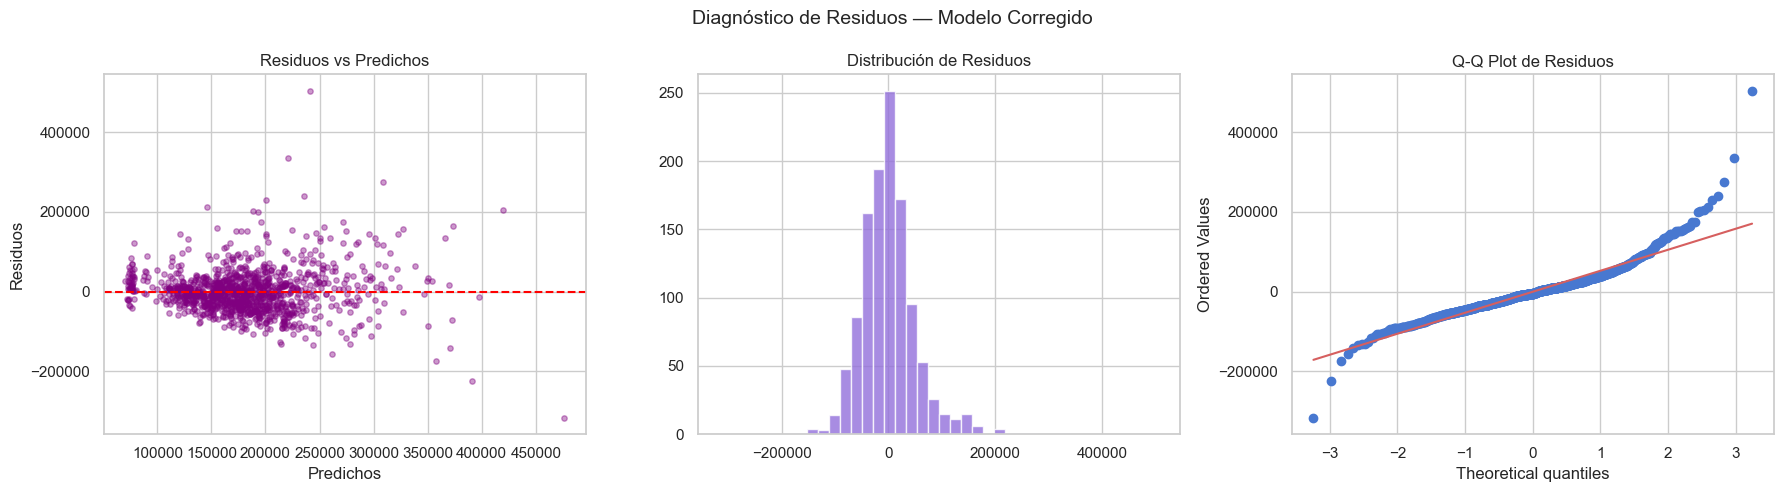

In [93]:
# Análisis de residuos — Modelo Corregido
y_pred_corr_train = model_corr.predict(sm.add_constant(X_corr_train))
y_pred_corr_test  = model_corr.predict(sm.add_constant(X_corr_test))
residuals_corr = y_train - y_pred_corr_train

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_corr_train, residuals_corr, alpha=0.4, s=15, color='purple')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuos vs Predichos'); axes[0].set_xlabel('Predichos'); axes[0].set_ylabel('Residuos')

axes[1].hist(residuals_corr, bins=40, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución de Residuos')

stats.probplot(residuals_corr, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot de Residuos')

plt.suptitle('Diagnóstico de Residuos — Modelo Corregido', fontsize=14)
plt.tight_layout()
plt.show()
